# Final EDA Summary Template

This notebook is a short shared template for final EDA summaries. Each EDA section has only three parts: research question, features/methods, and main findings.

Use the shared `df` loaded below when possible. If a section needs a different CSV, copy the loading cell inside that section and change the path there.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "summer26-pokemon-battle-predictor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# Tomorrow, change only this path if everyone is using the same parsed CSV.
PARSED_CSV_PATH = DATA_DIR / "data_cleaned.csv.zip"

print("Project root:", PROJECT_ROOT)
print("Parsed CSV path:", PARSED_CSV_PATH)

Project root: /Users/m/Documents/ml/erdos/github/summer26-pokemon-battle-predictor
Parsed CSV path: /Users/m/Documents/ml/erdos/github/summer26-pokemon-battle-predictor/data/data_cleaned.csv.zip


In [2]:
# Load the shared dataframe.
# Uncomment after PARSED_CSV_PATH points to the correct file.

# df = pd.read_csv(PARSED_CSV_PATH)

full_df = pd.read_csv(PARSED_CSV_PATH)
df = full_df[full_df["p1elo0"] > 0]

print(df.shape)
df.head()

(12381, 299)


,format,id,p1_win,ratedQ,n_turns,start_time,end_time,duration,p1name,p1side,p1elo0,p1elo1,p2name,p2side,p2elo0,p2elo1,type_diversity_diff,num_boosting_abilities_diff,num_move_boosters_diff,total_stat_diff,p1_total_adv,p1_revealed_team_size,p2_revealed_team_size,M11_name,M11_speciesId,M11_used,M11_gender,M11_shinyQ,M11_level,M11_ability,M11_item,M11_teraType,M11_role,M11_mv1,M11_mv2,M11_mv3,M11_mv4,M11_type1,M11_type2,M11_hp,M11_atk,M11_def,M11_spa,M11_spd,M11_spe,M11_off,M12_name,M12_speciesId,M12_used,M12_gender,...,M24_spa,M24_spd,M24_spe,M24_off,M25_name,M25_speciesId,M25_used,M25_gender,M25_shinyQ,M25_level,M25_ability,M25_item,M25_teraType,M25_role,M25_mv1,M25_mv2,M25_mv3,M25_mv4,M25_type1,M25_type2,M25_hp,M25_atk,M25_def,M25_spa,M25_spd,M25_spe,M25_off,M26_name,M26_speciesId,M26_used,M26_gender,M26_shinyQ,M26_level,M26_ability,M26_item,M26_teraType,M26_role,M26_mv1,M26_mv2,M26_mv3,M26_mv4,M26_type1,M26_type2,M26_hp,M26_atk,M26_def,M26_spa,M26_spd,M26_spe,M26_off
0,gen9randombattle,2642076539,0,True,21,1782884765,1782884937,172,Lirnom,1,1624,1607,Jenome,2,1674,1691,0,0,1,-79,3.125322,4,5,Cyclizar,cyclizar,1,M,False,83,Regenerator,Heavy-Duty Boots,Dragon,Fast Support,taunt,rapidspin,shedtail,dracometeor,Dragon,Normal,252,205,156,189,156,249,205,Cramorant,cramorant,1,M,...,182,118,158,198,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Life Orb,Steel,Fast Support,tripleaxel,synthesis,highjumpkick,powerwhip,Grass,NaN,267,259,220,137,220,175,259,Toxtricity,toxtricity,1,F,False,82,Punk Rock,Choice Specs,Normal,Fast Attacker,sludgewave,boomburst,voltswitch,overdrive,Electric,Poison,257,165,162,234,162,170,234
1,gen9randombattle,2642074504,1,True,7,1782884343,1782884385,42,jnpr010334,1,1651,1667,masajji,2,1582,1566,-1,-1,-2,19,0.997149,2,3,Virizion,virizion,1,N,False,82,Justified,Life Orb,Rock,Setup Sweeper,stoneedge,closecombat,swordsdance,leafblade,Grass,Fighting,283,195,165,195,259,224,195,Koraidon,koraidon,0,N,...,199,141,141,250,Gouging Fire,gougingfire,0,N,False,74,Protosynthesis,Heavy-Duty Boots,Fairy,Bulky Setup,heatcrash,morningsun,outrage,dragondance,Fire,Dragon,277,213,222,139,181,178,213,Zangoose,zangoose,1,M,False,85,Toxic Boost,Toxic Orb,Normal,Fast Attacker,knockoff,facade,swordsdance,closecombat,Normal,NaN,263,244,151,151,151,202,244
3,gen9randombattle,2641831207,1,True,51,1782847154,1782847410,256,soumatou_story,1,2113,2127,TheLastOne,2,2014,2000,-2,-2,2,347,3.903277,6,6,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Choice Scarf,Steel,Fast Support,tripleaxel,knockoff,powerwhip,uturn,Grass,NaN,267,259,220,137,220,175,259,Snorlax,snorlax,1,F,...,143,179,270,234,Hitmonchan,hitmonchan,1,M,False,87,Iron Fist,Leftovers,Steel,Bulky Support,encore,drainpunch,knockoff,poisonjab,Fighting,NaN,229,232,187,111,241,182,232,Corviknight,corviknight,1,M,False,80,Mirror Armor,Rocky Helmet,Dragon,Bulky Support,uturn,bodypress,bravebird,roost,Flying,Steel,288,185,214,131,182,153,185
4,gen9randombattle,2642210572,1,True,18,1782911409,1782911669,260,jobzy,1,1177,1201,danbur,2,1165,1141,0,2,1,-120,1.475808,2,6,Dewgong,dewgong,1,M,False,94,Thick Fat,Assault Vest,Poison,Bulky Attacker,knockoff,tripleaxel,surf,flipturn,Water,Ice,322,185,204,185,232,185,185,Iron Boulder,ironboulder,0,N,...,152,170,195,256,Jirachi,jirachi,1,N,False,80,Serene Grace,Leftovers,Water,Fast Support,bodyslam,ironhead,protect,wish,Steel,Psychic,291,206,206,206,206,206,206,Kyogre,kyogre,1,N,False,71,Drizzle,Choice Scarf,Water,Fast Attacker,thunder,waterspout,originpulse,icebeam,Water,NaN,259,147,169,254,240,169,254
5,gen9randombattle,2642086297,1,True,26,1782886873,1782887142,269,zero16132,1,1901,1920,jnpr010334,2,1956,1937,-1,-2,1,132,2.141758,4,6,Groudon,groudon,1,N,False,72,Drought,Leftovers,Fire,Bulky Setup,stoneedge,swordsdance,heatcrash,precipiceblades,Ground,NaN,263,258,244,186,172,172,258,Arboliva,arboliva,0,F,...,135,190,211,226,Archaludon,archaludon,1,M,False,78,Stamina,Lum Berry,Ground,Bulky Setup,earthquake,swordsdance,ironhead,outrage,Steel,Dragon,268,

See `data/README.md` for a thorough description of the column headers.

## 1. General Pokemon EDA

### Research Question

-

### Features Looking Into And Methods

Focus: General Pokemon stats, types, and team composition.

-

### Main Findings

-

In [3]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

## 2. First Pokemon Advantage EDA

### Research Question

- Is the first Pokemon sent out by the players significant enough affect the outcome of the match?

The first Pokemon sent out by the players is random and selected by the game algorithm. If a player sees that this is a bad matchup, they have the option to switch out the Pokemon, relinquishing the ability to use a Pokemon attack that turn. We explore the relations of some features to a player's win rate based on the first Pokemon only to see if they can be used to make a signifcant prediction for the outcome of the match. 

### Features Looking Into And Methods

This is relatively simple, we expore the numeric stats of the first Pokemon on each team along with their categorical types. 

### Main Findings

- It does not seem that differences for the numeric stats of the first Pokemon affect the outcome much. The medians are approximately the same and the distributions visually have the same spread in the boxplots. The correlation of the differences with the outcome are also all smaller than 0.015 in magnitude 
- On the other hand, if we look at the the winrate of the type of Player 1's Pokemon against the type of Player 2's Pokemon, in some instances the ratio is much smaller or larger than 0.5; see the heatmap below

We will proceed by testing a model that takes as input only the elo differential and the first Pokemon's type (note that the elo differential has been studied in other sections).

In [3]:
for col in df.columns:
    print(f"{col}: {df[col].dtype}, {df[col].nunique()} unique values")

format: str, 1 unique values
id: int64, 12381 unique values
p1_win: int64, 2 unique values
ratedQ: bool, 2 unique values
n_turns: int64, 104 unique values
start_time: int64, 12127 unique values
end_time: int64, 12061 unique values
duration: int64, 873 unique values
p1name: str, 5078 unique values
p1side: int64, 1 unique values
p1elo0: int64, 1396 unique values
p1elo1: int64, 1406 unique values
p2name: str, 4800 unique values
p2side: int64, 1 unique values
p2elo0: int64, 1460 unique values
p2elo1: int64, 1457 unique values
type_diversity_diff: int64, 13 unique values
num_boosting_abilities_diff: int64, 13 unique values
num_move_boosters_diff: int64, 13 unique values
total_stat_diff: int64, 1182 unique values
p1_total_adv: float64, 12381 unique values
p1_revealed_team_size: int64, 6 unique values
p2_revealed_team_size: int64, 6 unique values
M11_name: str, 418 unique values
M11_speciesId: str, 504 unique values
M11_used: int64, 1 unique values
M11_gender: str, 3 unique values
M11_shinyQ:

In [ ]:
X = df.copy()

features = ['p1_win',
            'p1elo0', 'M11_hp', 'M11_atk', 'M11_def', 'M11_spa', 'M11_spd', 'M11_spe', 'M11_type1', 'M11_type2',
            'p2elo0', 'M21_hp', 'M21_atk', 'M21_def', 'M21_spa', 'M21_spd', 'M21_spe', 'M21_type1', 'M21_type2']

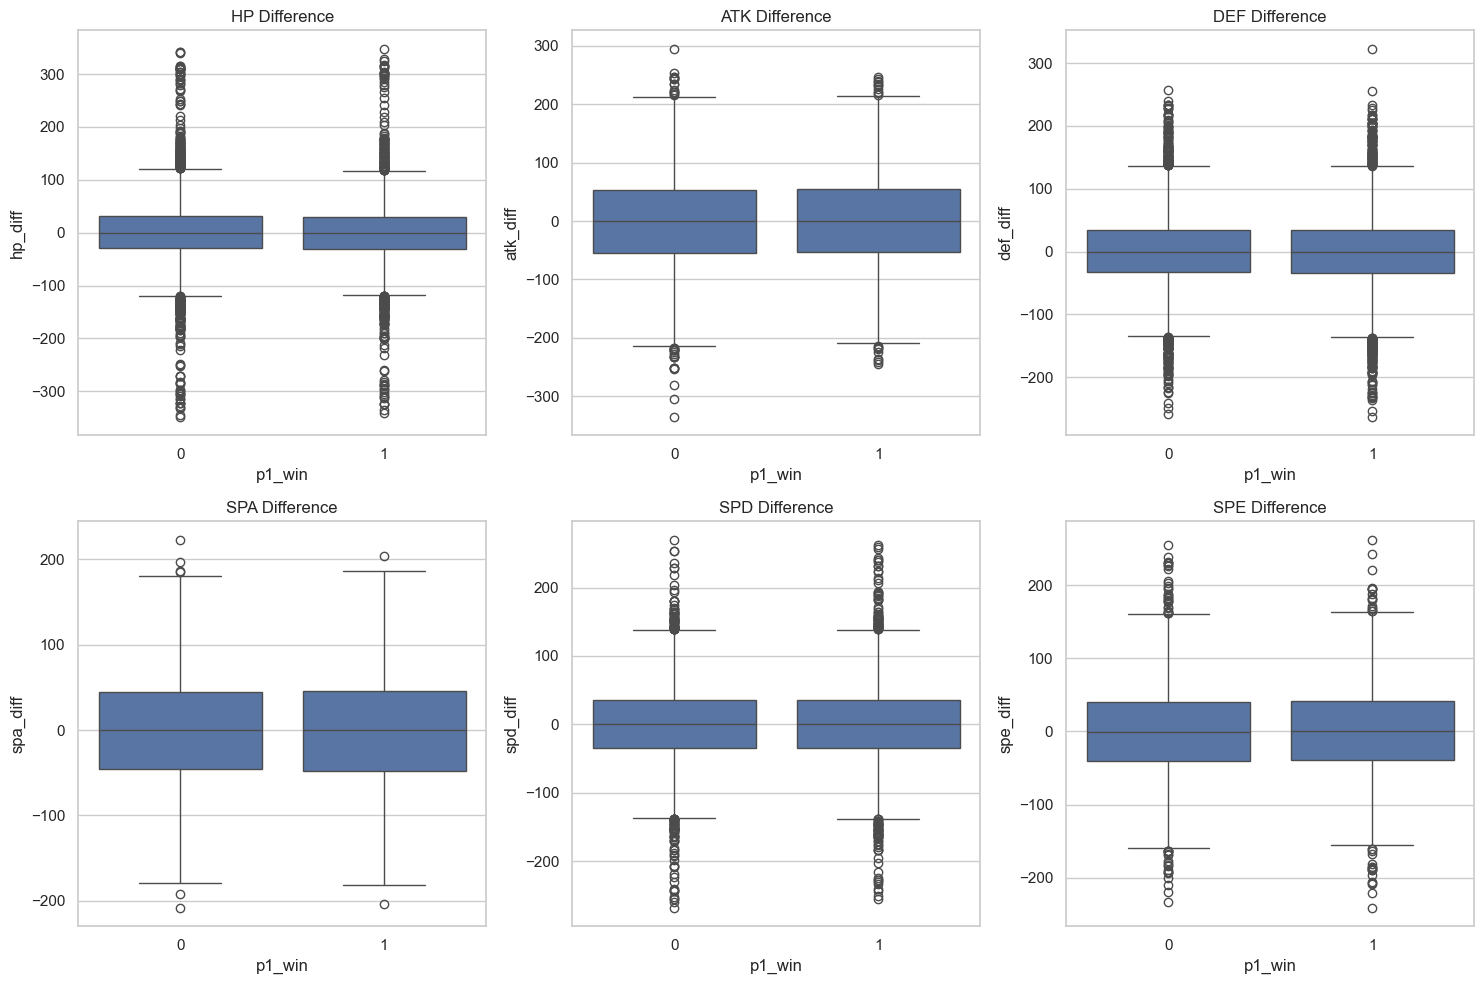

In [9]:
stats = ['hp', 'atk', 'def', 'spa', 'spd', 'spe']

# Calculate differences
for stat in stats:
    X[f'{stat}_diff'] = X[f'M11_{stat}'] - X[f'M21_{stat}']

# Plot differences against win status
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, stat in enumerate(stats):
    sns.boxplot(x='p1_win', y=f'{stat}_diff', data=X, ax=axes[i])
    axes[i].set_title(f'{stat.upper()} Difference')

plt.tight_layout()
plt.show()

In [ ]:
# check the correlation of the target with the features
features = []
for stat in stats:
    features.append(f'{stat}_diff')
features.append('p1_win')

print(X[features].corr(numeric_only=True)['p1_win'].sort_values(ascending=False))

p1_win      1.000000
spe_diff    0.013400
atk_diff    0.003355
spd_diff    0.002714
spa_diff   -0.006459
def_diff   -0.008445
hp_diff    -0.014571
Name: p1_win, dtype: float64


In [17]:
# check p1 win rate
print(X['p1_win'].mean())

0.47621355302479607


In [ ]:
# check the win rate by type of p1' pokemon
X.groupby('M11_type1')['p1_win'].mean()

M11_type1
Bug         0.470677
Dark        0.437416
Dragon      0.463415
Electric    0.483835
Fairy       0.494048
Fighting    0.505051
Fire        0.484076
Flying      0.473054
Ghost       0.464516
Grass       0.476471
Ground      0.486940
Ice         0.451193
Normal      0.483842
Poison      0.484733
Psychic     0.440789
Rock        0.491166
Steel       0.457090
Water       0.496355
Name: p1_win, dtype: float64

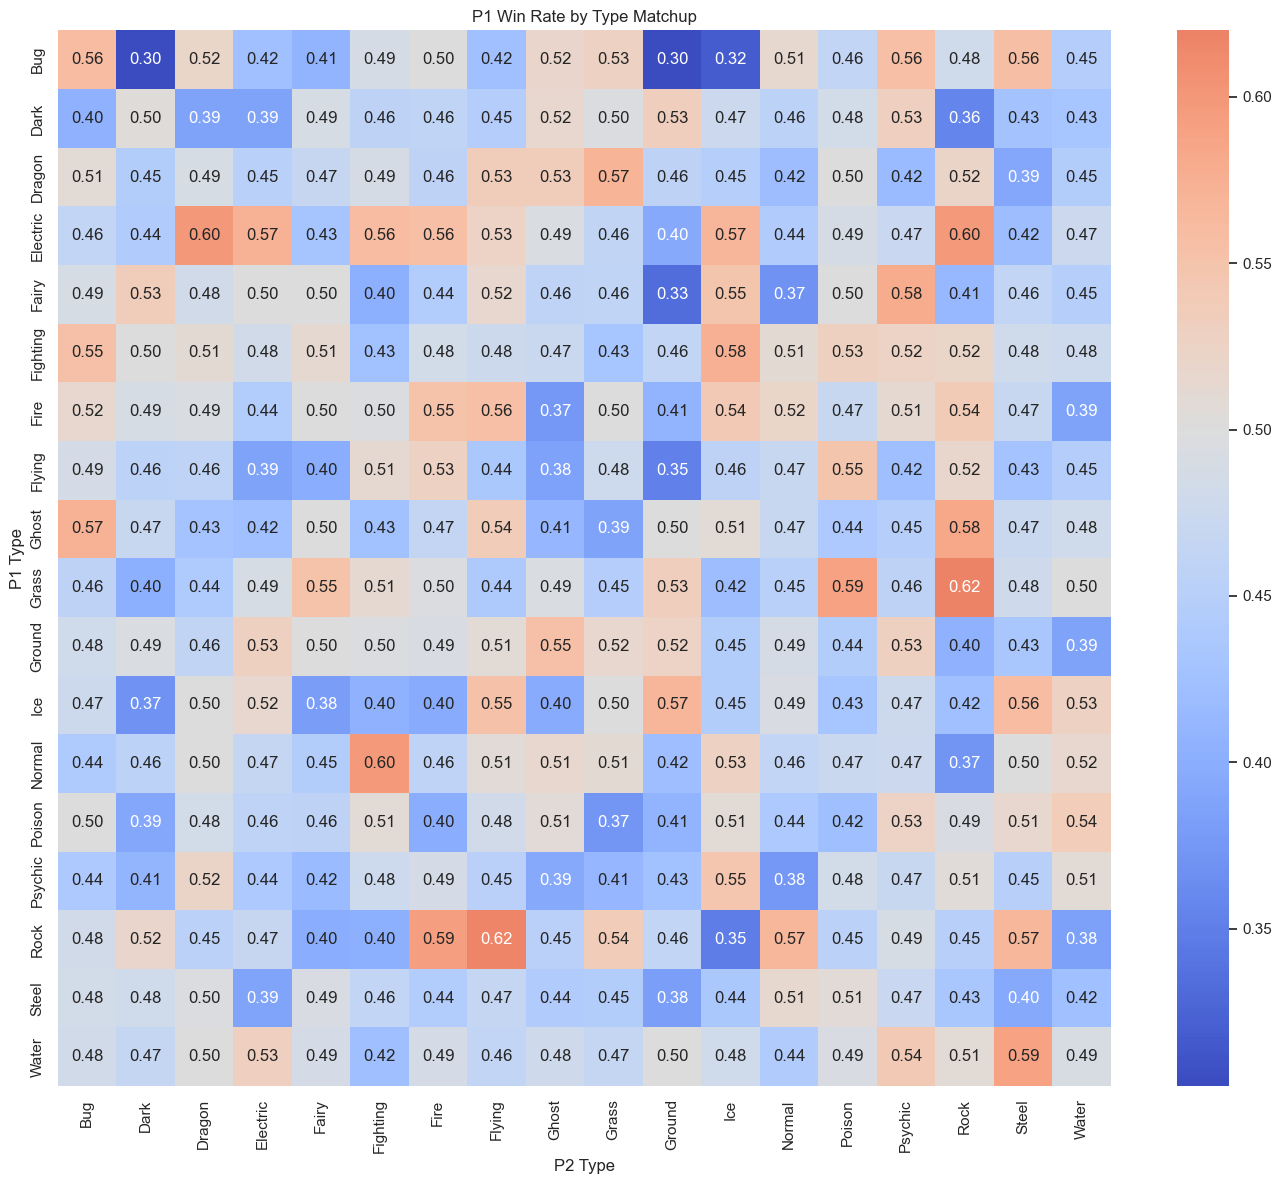

In [21]:
# In the heatmap below, we find the winrate of P1's pokemon against P2's pokemon based on their types
# Note, for example, if P1's pokemon has two types, and P2's pokemon has two types, we will count all four combinations of types in the winrate calculation

# Combine P1 and P2 types into lists, removing missing values
X['p1_types'] = X[['M11_type1', 'M11_type2']].values.tolist()
X['p2_types'] = X[['M21_type1', 'M21_type2']].values.tolist()

X['p1_types'] = X['p1_types'].apply(lambda x: [t for t in x if pd.notna(t) and t != 'None'])
X['p2_types'] = X['p2_types'].apply(lambda x: [t for t in x if pd.notna(t) and t != 'None'])

# Explode to get all combinations of P1 types vs P2 types per match
exploded_X = X.explode('p1_types').explode('p2_types')

# Calculate win rates and pivot into a matrix
win_matrix = exploded_X.groupby(['p1_types', 'p2_types'])['p1_win'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(win_matrix, cmap='coolwarm', annot=True, fmt=".2f", center=0.5)
plt.title('P1 Win Rate by Type Matchup')
plt.ylabel('P1 Type')
plt.xlabel('P2 Type')
plt.tight_layout()
plt.show()

## 3. Active Switch Count And Win Rate EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Relationship between active switches during battle and win rate.

-

### Main Findings

-

In [5]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

## 4. Pokemon Advantage Stats EDA

### Research Question

- 

### Features Looking Into And Methods

Focus: Pokemon advantage features and their relation to battle outcome.

-

### Main Findings

-

In [6]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

# Overall Takeaways

### Research Question

What did the combined EDA work help us understand about Pokemon battle prediction?

-

### Features Looking Into And Methods

-

### Main Findings

-